In [1]:
root_dir = '/vast/palmer/home.grace/zz436/neural_priming/'
import sys
sys.path.append(root_dir)
from priming_utils import *

import torch
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

from dataclasses import dataclass
from typing import Optional
import gc
import seaborn as sns
from tqdm.auto import tqdm
from transformer_lens import HookedTransformer, utils

torch.set_grad_enabled(True)

In [2]:
SIZE = 'large'
PRONOUN = False
SQUARED = True
file_Pronoun = 'Pronoun' if PRONOUN else 'NoPronoun'

In [3]:
model_name = f'gpt2-{SIZE}'
model = HookedTransformer.from_pretrained(model_name, device=device)

print(torch.cuda.get_device_properties(0).name)
print(torch.cuda.get_device_properties(0).total_memory/1000000)
print(torch.cuda.memory_reserved(device=device)/1000000)
filler_path = f'{root_dir}fine-tuning/fillers_mid.txt'

with open(filler_path, 'r') as f:
    fillers = [line.strip() for line in f.readlines()]
print(f'The set of {len(fillers)} fillers.')

with torch.no_grad():
    if SIZE == 'small':
        raw_loss = model(fillers, return_type="loss").detach()
    else:
        raw_loss = []
        for filler in fillers:
            raw_loss.append(model(filler, return_type="loss").detach())

Loaded pretrained model gpt2-large into HookedTransformer
NVIDIA A100-PCIE-40GB
42297.786368
3546.284032
The set of 30 fillers.


In [11]:
@dataclass
class HookedTransformerTrainConfig:
    num_epochs: int
    batch_size: int
    lr: float = 1e-5
    lamb: float = 0.0
    seed: int = 0
    
    momentum: float = 0.0
    max_grad_norm: Optional[float] = None
    weight_decay: Optional[float] = None
    optimizer_name: str = "Adam"
    
    device: Optional[str] = None
    warmup_steps: int = 0
    save_every: Optional[int] = None
    save_dir: Optional[str] = None

    print_every: Optional[int] = None
    max_steps: Optional[int] = None

def train(
    model: HookedTransformer,
    config: HookedTransformerTrainConfig,
    dataset: Dataset,
    raw_loss: float
) -> HookedTransformer:
    torch.manual_seed(config.seed)
    model.train()

    if config.device is None:
        config.device = utils.get_device()

    if config.optimizer_name in ["Adam", "AdamW"]:
        # Weight decay in Adam is implemented badly, so use AdamW instead (see PyTorch AdamW docs)
        if config.weight_decay is not None:
            optimizer = optim.AdamW(
                model.parameters(),
                lr=config.lr,
                weight_decay=config.weight_decay,
            )
        else:
            optimizer = optim.Adam(
                model.parameters(),
                lr=config.lr,
            )
    elif config.optimizer_name == "SGD":
        optimizer = optim.SGD(
            model.parameters(),
            lr=config.lr,
            weight_decay=config.weight_decay
            if config.weight_decay is not None
            else 0.0,
            momentum=config.momentum,
        )
    else:
        raise ValueError(f"Optimizer {config.optimizer_name} not supported")

    scheduler = None
    if config.warmup_steps > 0:
        scheduler = optim.lr_scheduler.LambdaLR(
            optimizer,
            lr_lambda=lambda step: min(1.0, step / config.warmup_steps),
        )

    dataloader = DataLoader(dataset, batch_size=config.batch_size, shuffle=True)

    model.to(config.device)
    for epoch in range(1, config.num_epochs + 1):
        samples = 0
        for step, batch in enumerate(dataloader):
            tokens = batch["tokens"].to(config.device)
            loss = model(tokens, return_type="loss")
            loss.backward()

            if SIZE == 'small':
                loss_reg = model(fillers, return_type="loss")
                loss = config.lamb * ((loss_reg - raw_loss)**2)
                print(f'At epoch {epoch}, before backward: {torch.cuda.memory_reserved(device=device)/1000000}')
                loss.backward()
                print(f'At epoch {epoch}, AFTER backward: {torch.cuda.memory_reserved(device=device)/1000000}')
            else:
                loss_reg = 0
                for idx, filler in enumerate(fillers):
                    loss_reg = model(filler, return_type="loss")
                    loss = config.lamb * (loss_reg - raw_loss[idx]) # may want to divide by 30 if we think this as averaging
                    loss.backward()
            print(torch.cuda.memory_reserved(device=device)/1000000)
            
            
            if config.max_grad_norm is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), config.max_grad_norm)
            optimizer.step()
            if config.warmup_steps > 0:
                assert scheduler is not None
                scheduler.step()
            optimizer.zero_grad()

            samples += tokens.shape[0]

            if config.print_every is not None and step % config.print_every == 0:
                print(f"Epoch {epoch} Samples {samples} Step {step} Loss {loss.item()}")

            if (
                config.save_every is not None
                and step % config.save_every == 0
                and config.save_dir is not None
            ):
                torch.save(model.state_dict(), f"{config.save_dir}/model_{step}.pt")

            if config.max_steps is not None and step >= config.max_steps:
                break
                
        torch.cuda.empty_cache()
        gc.collect()

    return model

class FineTuningDataset(Dataset):
    def __init__(self, data, max_length=15, padding=False):
        self.data = data
        self.max_length = max_length
        self.pad_idx = 50256
        self.padding = padding

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        if not self.padding:
            return {'tokens': model.to_tokens(self.data[idx]).squeeze(0)}
        else:
            temp = model.to_tokens(self.data[idx]).tolist()[0]
            temp.extend([50256] * (self.max_length - len(temp)))
            toks = torch.tensor(temp)
            return {'tokens': toks}

def get_log_prob(sentence, output):
    probs = nn.functional.log_softmax(output.squeeze()[:-1, :], dim=-1)
    probs = probs[range(probs.size(0)), model.to_tokens(sentence).squeeze(0).tolist()[1:]]
    return torch.sum(probs).item(), list(probs.cpu().detach().numpy())

In [14]:
def train_original(
    model: HookedTransformer,
    config: HookedTransformerTrainConfig,
    dataset: Dataset,
    raw_loss: float
) -> HookedTransformer:
    torch.manual_seed(config.seed)
    model.train()

    if config.device is None:
        config.device = utils.get_device()

    if config.optimizer_name in ["Adam", "AdamW"]:
        # Weight decay in Adam is implemented badly, so use AdamW instead (see PyTorch AdamW docs)
        if config.weight_decay is not None:
            optimizer = optim.AdamW(
                model.parameters(),
                lr=config.lr,
                weight_decay=config.weight_decay,
            )
        else:
            optimizer = optim.Adam(
                model.parameters(),
                lr=config.lr,
            )
    elif config.optimizer_name == "SGD":
        optimizer = optim.SGD(
            model.parameters(),
            lr=config.lr,
            weight_decay=config.weight_decay
            if config.weight_decay is not None
            else 0.0,
            momentum=config.momentum,
        )
    else:
        raise ValueError(f"Optimizer {config.optimizer_name} not supported")

    scheduler = None
    if config.warmup_steps > 0:
        scheduler = optim.lr_scheduler.LambdaLR(
            optimizer,
            lr_lambda=lambda step: min(1.0, step / config.warmup_steps),
        )

    dataloader = DataLoader(dataset, batch_size=config.batch_size, shuffle=True)

    model.to(config.device)
    for epoch in range(1, config.num_epochs + 1):
        samples = 0
        for step, batch in enumerate(dataloader):
            tokens = batch["tokens"].to(config.device)
            loss = model(tokens, return_type="loss")
            
            loss_reg = model(fillers, return_type="loss")
            if SQUARED:
                loss += config.lamb * ((loss_reg - raw_loss)**2)
                print(f'At epoch {epoch}, before backward: {torch.cuda.memory_reserved(device=device)/1000000}')
            else:
                loss += config.lamb * (loss_reg - raw_loss)
            
            loss.backward()
            print(f'At epoch {epoch}, AFTER backward: {torch.cuda.memory_reserved(device=device)/1000000}')
            
            
            if config.max_grad_norm is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), config.max_grad_norm)
            optimizer.step()
            if config.warmup_steps > 0:
                assert scheduler is not None
                scheduler.step()
            optimizer.zero_grad()

            samples += tokens.shape[0]

            if config.print_every is not None and step % config.print_every == 0:
                print(f"Epoch {epoch} Samples {samples} Step {step} Loss {loss.item()}")

            if (
                config.save_every is not None
                and step % config.save_every == 0
                and config.save_dir is not None
            ):
                torch.save(model.state_dict(), f"{config.save_dir}/model_{step}.pt")

            if config.max_steps is not None and step >= config.max_steps:
                break
                
        torch.cuda.empty_cache()
        gc.collect()

    return model

In [6]:
raw_model = HookedTransformer.from_pretrained(model_name, device=device)

targetPD = 'A soldier brought a cup to a scientist.'
targetDO = 'A soldier brought a scientist a cup.'

output_PD = raw_model(targetPD)
output_DO = raw_model(targetDO)


baseline_PD,_ = get_log_prob(targetPD, output_PD)
baseline_DO,_ = get_log_prob(targetDO, output_DO)

print(f'{baseline_PD}, {baseline_DO}')

Loaded pretrained model gpt2-large into HookedTransformer
-47.83038330078125, -45.99716567993164


In [12]:
torch.cuda.empty_cache()
gc.collect()
print(torch.cuda.memory_reserved(device=device)/1000000)

9365.880832


# Testing whether the step-wise `loss.backward()` works

### On GPT2-small: conclusion = backward doesn't modify model behavior

In [17]:
LR = 1e-5
LAMB = 0.8

In [18]:
raw_model = HookedTransformer.from_pretrained(model_name, device=device)
torch.cuda.empty_cache()
gc.collect()

train_config = HookedTransformerTrainConfig(
    num_epochs=10,
    batch_size=1,
    lr=LR,
    lamb = LAMB,
    optimizer_name="AdamW")

data = ['The professor made the key for the president.']
dataset = FineTuningDataset(data)
adapted_model = train_original(raw_model, train_config, dataset, raw_loss)
output_PD = adapted_model(targetPD)
output_DO = adapted_model(targetDO)

sen_prob_PD,_ = get_log_prob(targetPD, output_PD)
sen_prob_DO,_ = get_log_prob(targetDO, output_DO)

sen_prob_PD, sen_prob_DO

Loaded pretrained model gpt2-small into HookedTransformer
Moving model to device:  cuda
At epoch 1, before backward: 19805.503488
At epoch 1, AFTER backward: 22819.110912
At epoch 2, before backward: 21181.2352
At epoch 2, AFTER backward: 24192.745472
At epoch 3, before backward: 21181.2352
At epoch 3, AFTER backward: 24192.745472
At epoch 4, before backward: 21181.2352
At epoch 4, AFTER backward: 24192.745472
At epoch 5, before backward: 21181.2352
At epoch 5, AFTER backward: 24192.745472
At epoch 6, before backward: 21181.2352
At epoch 6, AFTER backward: 24192.745472
At epoch 7, before backward: 21181.2352
At epoch 7, AFTER backward: 24192.745472
At epoch 8, before backward: 21181.2352
At epoch 8, AFTER backward: 24192.745472
At epoch 9, before backward: 21181.2352
At epoch 9, AFTER backward: 24192.745472
At epoch 10, before backward: 21181.2352
At epoch 10, AFTER backward: 24192.745472


(-47.20692443847656, -48.091468811035156)

In [19]:
raw_model = HookedTransformer.from_pretrained(model_name, device=device)
torch.cuda.empty_cache()
gc.collect()

train_config = HookedTransformerTrainConfig(
    num_epochs=10,
    batch_size=1,
    lr=LR,
    lamb = LAMB,
    optimizer_name="AdamW")

data = ['The professor made the key for the president.']
dataset = FineTuningDataset(data)
adapted_model = train(raw_model, train_config, dataset, raw_loss)
output_PD = adapted_model(targetPD)
output_DO = adapted_model(targetDO)

sen_prob_PD,_ = get_log_prob(targetPD, output_PD)
sen_prob_DO,_ = get_log_prob(targetDO, output_DO)

sen_prob_PD, sen_prob_DO

Loaded pretrained model gpt2-small into HookedTransformer
Moving model to device:  cuda
At epoch 1, before backward: 19646.119936
At epoch 1, AFTER backward: 22657.630208
At epoch 2, before backward: 21005.074432
At epoch 2, AFTER backward: 24016.584704
At epoch 3, before backward: 21005.074432
At epoch 3, AFTER backward: 24016.584704
At epoch 4, before backward: 21005.074432
At epoch 4, AFTER backward: 24016.584704
At epoch 5, before backward: 21005.074432
At epoch 5, AFTER backward: 24016.584704
At epoch 6, before backward: 21005.074432
At epoch 6, AFTER backward: 24016.584704
At epoch 7, before backward: 21005.074432
At epoch 7, AFTER backward: 24016.584704
At epoch 8, before backward: 21005.074432
At epoch 8, AFTER backward: 24016.584704
At epoch 9, before backward: 21005.074432
At epoch 9, AFTER backward: 24016.584704
At epoch 10, before backward: 21005.074432
At epoch 10, AFTER backward: 24016.584704


(-47.20692443847656, -48.091468811035156)

### On GPT2-large

In [15]:
LR = 1e-5
LAMB = 0.8

In [16]:
raw_model = HookedTransformer.from_pretrained(model_name, device=device)
torch.cuda.empty_cache()
gc.collect()

train_config = HookedTransformerTrainConfig(
    num_epochs=10,
    batch_size=1,
    lr=LR,
    lamb = LAMB,
    optimizer_name="AdamW")

data = ['The professor made the key for the president.']
dataset = FineTuningDataset(data)
adapted_model = train(raw_model, train_config, dataset, raw_loss)
output_PD = adapted_model(targetPD)
output_DO = adapted_model(targetDO)

sen_prob_PD,_ = get_log_prob(targetPD, output_PD)
sen_prob_DO,_ = get_log_prob(targetDO, output_DO)

print(sen_prob_PD, sen_prob_DO)
print(sen_prob_PD - baseline_PD, sen_prob_DO - baseline_DO)

Loaded pretrained model gpt2-large into HookedTransformer
Moving model to device:  cuda
20191.379456
27028.094976
27028.094976
27028.094976
27028.094976
27028.094976
27028.094976
27028.094976
27028.094976
27028.094976
-49.077701568603516 -46.381072998046875
-1.2473182678222656 -0.3839073181152344


# Search Through Hyper-combinations

### The function for recording search results

In [11]:
rec = []
torch.cuda.empty_cache()
gc.collect()

for LAMB in [0.5, 1, 5, 10, 20, 50]: #0.1, 
    print(f'############################ Lamb = {LAMB} ############################')
    for LR in [5e-7, 1e-6, 5e-6, 1e-5, 5e-5]:#1e-7, 1e-4, 5e-4
        print(f'########### Lr = {LR} ###########')
        raw_model = HookedTransformer.from_pretrained(model_name, device=device)
        
        train_config = HookedTransformerTrainConfig(
            num_epochs=10,
            batch_size=1,
            lr=LR,
            lamb = LAMB,
            optimizer_name="AdamW")

        data = ['The professor made the key for the president.']
        dataset = FineTuningDataset(data)
        adapted_model = train(raw_model, train_config, dataset, raw_loss)
        output_PD = adapted_model(targetPD)
        output_DO = adapted_model(targetDO)
        
        sen_prob_PD,_ = get_log_prob(targetPD, output_PD)
        sen_prob_DO,_ = get_log_prob(targetDO, output_DO)

                    'lr': train_config.lr,
                    'PD': sen_prob_PD - baseline_PD,
                    'DO': sen_prob_DO - baseline_DO})
        #print(f'lambda = {train_config.lamb}, lr = {train_config.lr}, {sen_prob_PD - baseline_PD}, {sen_prob_DO - baseline_DO}')
        torch.cuda.empty_cache()
        gc.collect()
    
df = pd.DataFrame(rec)
df.to_csv(f'{root_dir}fine-tuning/Hyperparameter/Hypersearch_large_squared_fullFiller.csv', index=False)

############################ Lamb = 0.5 ############################
########### Lr = 5e-07 ###########
Loaded pretrained model gpt2-large into HookedTransformer
Moving model to device:  cuda
13847.494656
15829.303296
15829.303296
17574.13376
17574.13376
18935.185408
18935.185408
20680.015872
20680.015872
21781.020672
21781.020672
23785.897984
23785.897984
25797.066752
25797.066752
27046.969344
27046.969344
29173.481472
29173.481472
32075.93984
32075.93984
33512.48896
33512.48896
34777.071616
34777.071616
36760.977408
36760.977408
37878.759424
37878.759424
40225.472512
40225.472512
41265.659904
41265.659904


OutOfMemoryError: CUDA out of memory. Tried to allocate 2.00 MiB. GPU 0 has a total capacty of 39.39 GiB of which 2.81 MiB is free. Including non-PyTorch memory, this process has 39.38 GiB memory in use. Of the allocated memory 38.76 GiB is allocated by PyTorch, and 126.79 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF

### Plotting the results

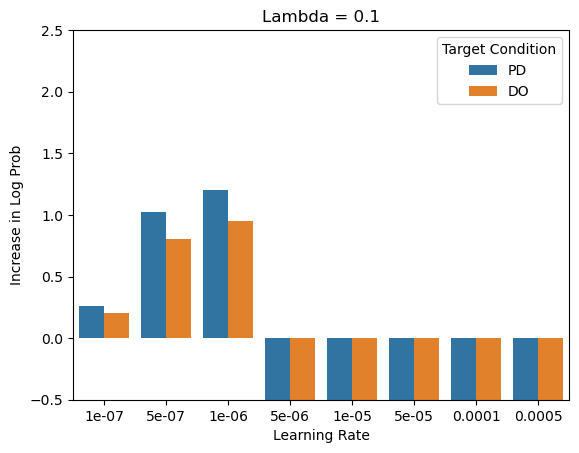

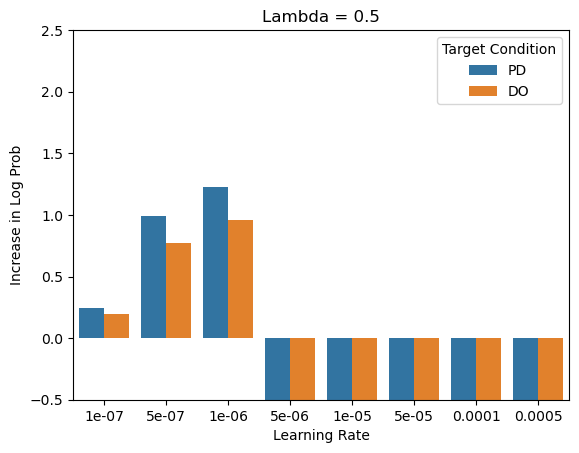

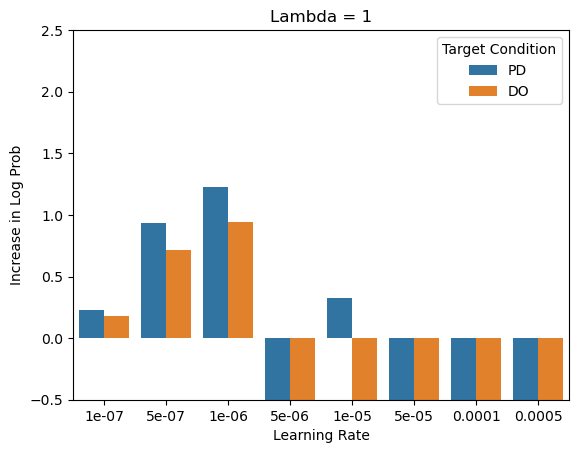

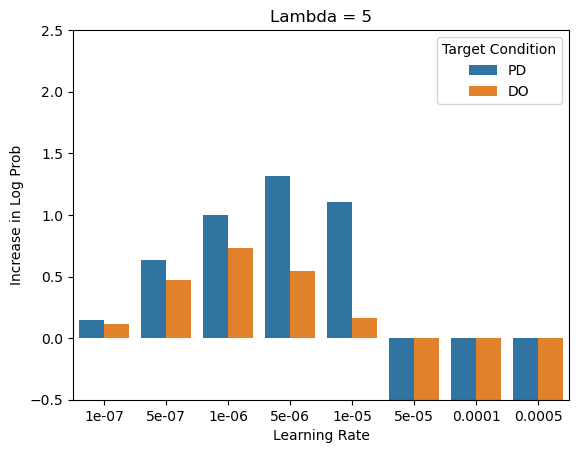

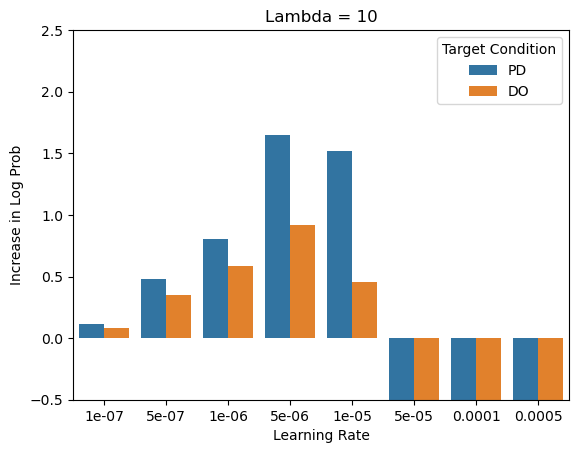

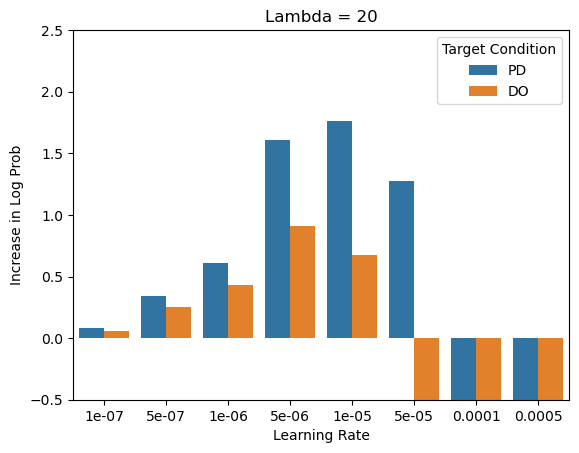

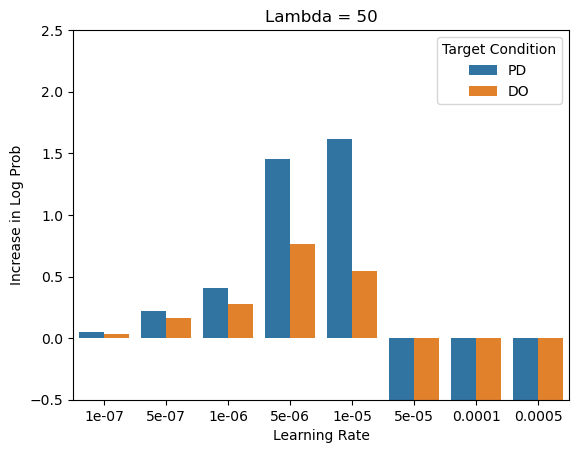

In [9]:
df = pd.read_csv(f'{root_dir}fine-tuning/Hyperparameter/Hypersearch_large.csv')
# iterate and change the large negative values to -0.5
df.loc[df['PD']<0, 'PD'] = -0.5
df.loc[df['DO']<0, 'DO'] = -0.5

for LAMB in [0.1, 0.5, 1, 5, 10, 20, 50]:
    df_sub = df[df['lambda'] == LAMB][['lr','PD','DO']]
    df_melted = df_sub.melt(id_vars = 'lr', var_name='Target Condition', value_name='Priming Dev')
    sns.barplot(data=df_melted, x='lr', y='Priming Dev', hue='Target Condition')
    plt.ylim(-0.5, 2.5)
    plt.xlabel('Learning Rate')
    plt.ylabel('Increase in Log Prob')
    plt.title(f'Lambda = {LAMB}')
    plt.show()

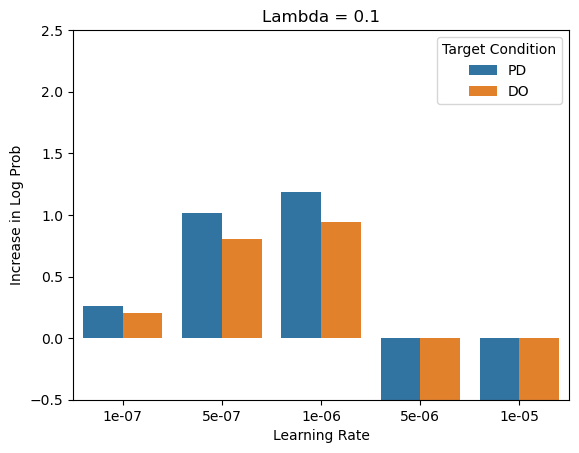

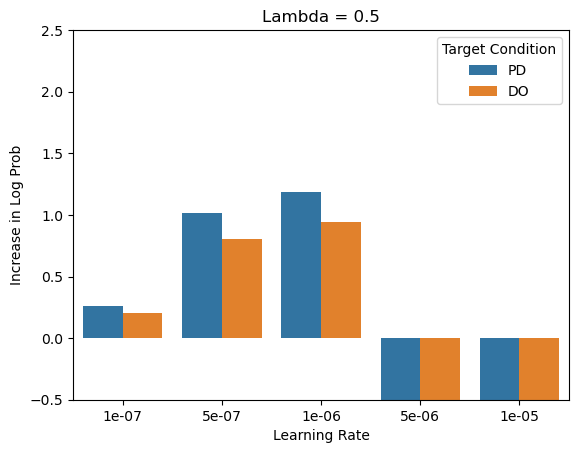

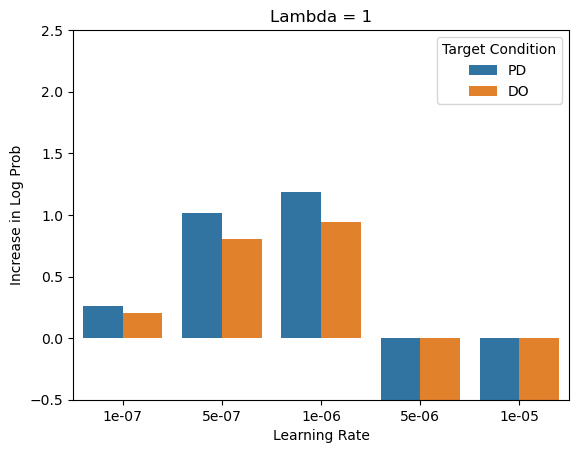

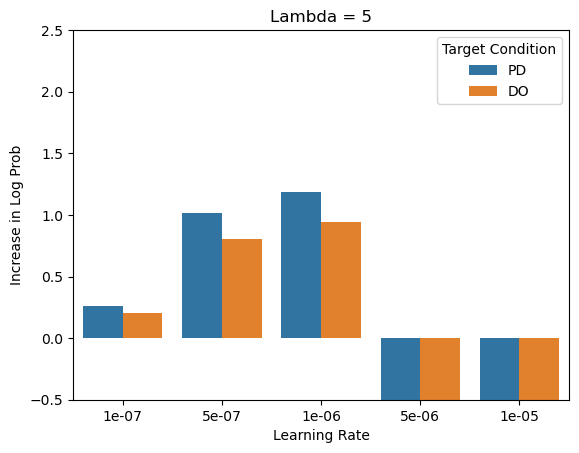

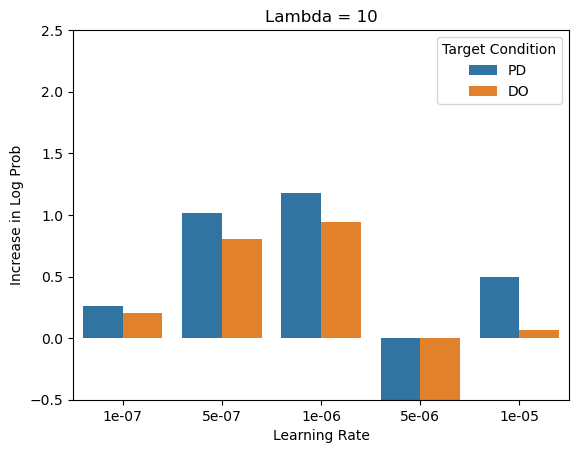

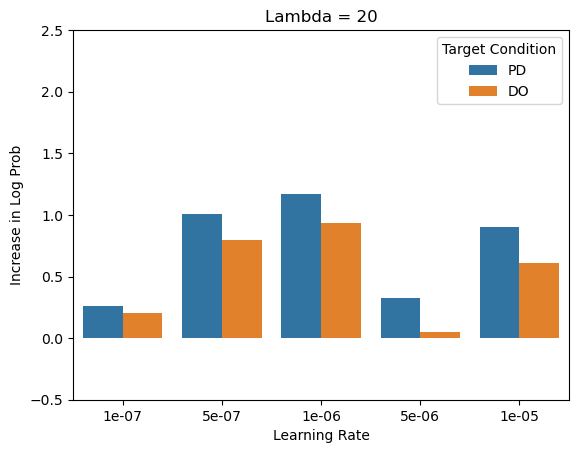

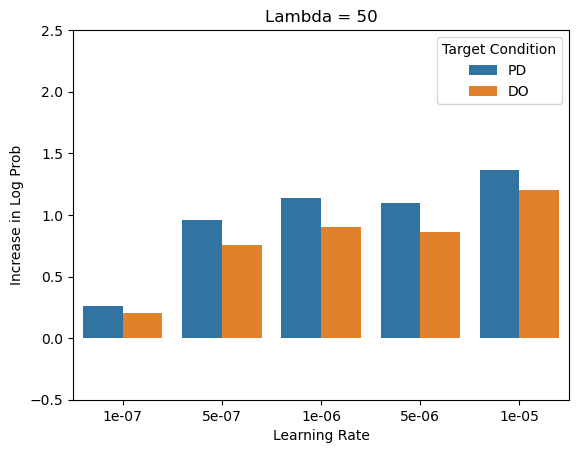

In [8]:
df = pd.read_csv(f'{root_dir}fine-tuning/Hyperparameter/Hypersearch_large_squared.csv')
# iterate and change the large negative values to -0.5
df.loc[df['PD']<0, 'PD'] = -0.5
df.loc[df['DO']<0, 'DO'] = -0.5

for LAMB in [0.1, 0.5, 1, 5, 10, 20, 50]:
    df_sub = df[df['lambda'] == LAMB][['lr','PD','DO']]
    df_melted = df_sub.melt(id_vars = 'lr', var_name='Target Condition', value_name='Priming Dev')
    sns.barplot(data=df_melted, x='lr', y='Priming Dev', hue='Target Condition')
    plt.ylim(-0.5, 2.5)
    plt.xlabel('Learning Rate')
    plt.ylabel('Increase in Log Prob')
    plt.title(f'Lambda = {LAMB}')
    plt.show()

In [ ]:
df = pd.read_csv(f'{root_dir}fine-tuning/Hyperparameter/Hypersearch_large_squared_fullFiller.csv')
# iterate and change the large negative values to -0.5
df.loc[df['PD']<0, 'PD'] = -0.5
df.loc[df['DO']<0, 'DO'] = -0.5

for LAMB in [0.5, 1, 5, 10, 20, 50]:
    df_sub = df[df['lambda'] == LAMB][['lr','PD','DO']]
    df_melted = df_sub.melt(id_vars = 'lr', var_name='Target Condition', value_name='Priming Dev')
    sns.barplot(data=df_melted, x='lr', y='Priming Dev', hue='Target Condition')
    plt.ylim(-0.5, 2.5)
    plt.xlabel('Learning Rate')
    plt.ylabel('Increase in Log Prob')
    plt.title(f'Lambda = {LAMB}')
    plt.show()